In [4]:
import pandas as pd
import numpy as np

sample_data = {
    'PassengerId': [1, 2, 3, 4, 5],
    'Survived': [0, 1, 1, 1, 0],
    'Pclass': [3, 1, 3, 1, 3],
    'Name': [
        "Rishi",
        "Mithra",
        "Mahi",
        "Manvi",
        "Ruthra"
    ],
    'Sex': ['male', 'female', 'female', 'female', 'male'],
    'Age': [22, 38, 26, 35, np.nan],
    'SibSp': [1, 1, 0, 1, 0],
    'Parch': [0, 0, 0, 0, 0],
    'Ticket': ['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450'],
    'Fare': [7.25, 71.2833, 7.925, 53.1, 8.05],
    'Cabin': [np.nan, 'C85', np.nan, 'C123', np.nan],
    'Embarked': ['S', 'C', 'S', 'S', np.nan]
}

df = pd.DataFrame(sample_data)
df.to_csv("titanic.csv", index=False)

Shape of dataset: (5, 12)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  5 non-null      int64  
 1   Survived     5 non-null      int64  
 2   Pclass       5 non-null      int64  
 3   Name         5 non-null      object 
 4   Sex          5 non-null      object 
 5   Age          4 non-null      float64
 6   SibSp        5 non-null      int64  
 7   Parch        5 non-null      int64  
 8   Ticket       5 non-null      object 
 9   Fare         5 non-null      float64
 10  Cabin        2 non-null      object 
 11  Embarked     4 non-null      object 
dtypes: float64(2), int64(5), object(5)
memory usage: 612.0+ bytes
None

Summary Statistics:

       PassengerId  Survived    Pclass    Age     SibSp  Parch       Fare
count     5.000000  5.000000  5.000000   4.00  5.000000    5.0   5.000000
mean      3.000000  0.60000

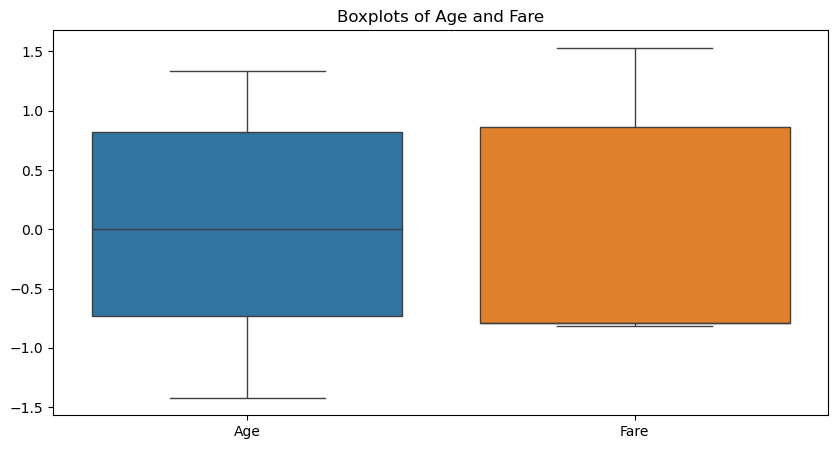


 Cleaned dataset saved as 'titanic_cleaned.csv'


In [5]:
# Titanic Dataset - Data Cleaning & Preprocessing

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("titanic.csv")  # Ensure the CSV is in the same directory

# Step 1: Explore Dataset - Shape, Info, and Summary
print("Shape of dataset:", df.shape)
print("\nDataset Info:\n")
print(df.info())
print("\nSummary Statistics:\n")
print(df.describe())
print("\nFirst 5 Rows:\n")
print(df.head())

# Step 2: Handle Missing Values
print("\nMissing values before handling:\n", df.isnull().sum())

# Fill missing numerical values (Age)
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing categorical values (Embarked)
if not df['Embarked'].mode().empty:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
else:
    df['Embarked'] = df['Embarked'].fillna('S')  # Default fallback

# Drop 'Cabin' column due to too many missing values
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

print("\nMissing values after handling:\n", df.isnull().sum())

# Step 3: Convert Categorical to Numerical
# Label Encoding for 'Sex'
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-Hot Encoding for 'Embarked'
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Step 4: Standardize Numerical Features
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Step 5: Visualize and Remove Outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Age', 'Fare']])
plt.title("Boxplots of Age and Fare")
plt.show()

# Function to remove outliers using IQR
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

# Apply outlier removal
df = remove_outliers(df, 'Age')
df = remove_outliers(df, 'Fare')

# Save the cleaned dataset
df.to_csv("titanic_cleaned.csv", index=False)
print("\n Cleaned dataset saved as 'titanic_cleaned.csv'")
